## 1.业务背景

##### 该公司是一家全球性的电子消费产品的电商公司，该公司需要从2019-2022疫情期间分析销售趋势，以取得对公司业务进一步发展的洞见，以下是收集到的数据以及基本情况的分析

## 2.查看数据的基本情况 决定使用什么工具进行后续的分析

##### 可以看到工作簿包含两个工作表，下面逐一查看工作表的基本情况

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
excel_file = pd.ExcelFile('gamezone-orders-data.xlsx')
sheet_names = excel_file.sheet_names
print("工作表名称:", sheet_names)

工作表名称: ['orders', 'region']


In [30]:
elist_order = pd.read_excel("gamezone-orders-data.xlsx", sheet_name='orders')
elist_order.head()

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,REFUND_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,Unnamed: 12,Unnamed: 13
0,2c06175e,0001328c3c220830,2020-12-24 00:00:00,2020-12-13,NaT,Nintendo Switch,e682,168.00,website,affiliate,unknown,US,NaN,#REF!
1,ee8e5bc2,0002af7a5c6100772,2020-10-01 00:00:00,2020-09-21,NaT,Nintendo Switch,e682,160.61,website,direct,desktop,DE,NaN,NaN
2,9eb4efe0,0002b8350e167074,2020-04-21 00:00:00,2020-02-16,NaT,Nintendo Switch,8d0d,151.20,website,direct,desktop,US,NaN,NaN
3,cac7cbaf,0006d06b98385729,2020-04-07 00:00:00,2020-04-04,2022-04-28,Sony PlayStation 5 Bundle,54ed,1132.82,website,direct,desktop,AU,NaN,NaN
4,6b0230bc,00097279a2f46150,2020-11-24 00:00:00,2020-08-02,NaT,Nintendo Switch,8d0d,33.89,website,direct,desktop,TR,NaN,NaN


#### 该数据表包含14个字段，21864个数据点以及数据类型，字段包含的数据类型包括日期，整数，浮点数，对象

#### 同时查看数值数据的基本趋势，中位数，众数，最大最小值，平均值等

In [31]:
print(elist_order.shape)
print(elist_order.dtypes)
elist_order.describe()

(21864, 14)
USER_ID                            object
ORDER_ID                           object
PURCHASE_TS                        object
SHIP_TS                    datetime64[ns]
REFUND_TS                  datetime64[ns]
PRODUCT_NAME                       object
PRODUCT_ID                         object
USD_PRICE                         float64
PURCHASE_PLATFORM                  object
MARKETING_CHANNEL                  object
ACCOUNT_CREATION_METHOD            object
COUNTRY_CODE                       object
Unnamed: 12                       float64
Unnamed: 13                        object
dtype: object


,SHIP_TS,REFUND_TS,USD_PRICE,Unnamed: 12
count,21864,3487,21859.000000,0.0
mean,2020-04-15 16:04:48.474204160,2022-12-10 22:58:28.115858944,281.406583,NaN
min,2018-10-18 00:00:00,2020-11-28 00:00:00,0.000000,NaN
25%,2019-11-12 00:00:00,2022-03-30 12:00:00,126.000000,NaN
50%,2020-05-23 00:00:00,2022-09-20 00:00:00,168.000000,NaN
75%,2020-10-06 00:00:00,2023-05-02 12:00:00,357.000000,NaN
max,2021-11-16 00:00:00,2026-03-14 00:00:00,3146.880000,NaN
std,NaN,NaN,366.296410,NaN


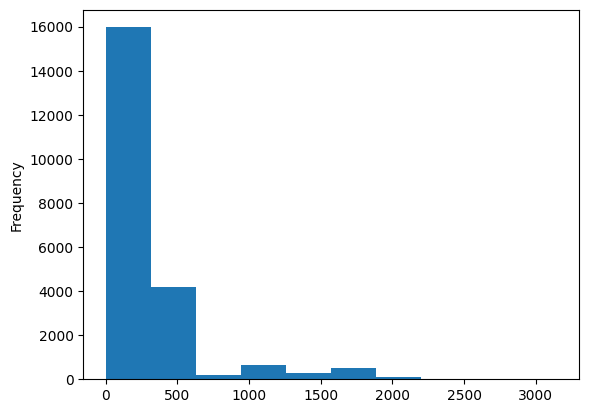

In [40]:
plt_price = elist_order['USD_PRICE'].plot(kind='hist')

In [41]:
elist_order.columns

Index(['USER_ID', 'ORDER_ID', 'PURCHASE_TS', 'SHIP_TS', 'REFUND_TS',
       'PRODUCT_NAME', 'PRODUCT_ID', 'USD_PRICE', 'PURCHASE_PLATFORM',
       'MARKETING_CHANNEL', 'ACCOUNT_CREATION_METHOD', 'COUNTRY_CODE',
       'Unnamed: 12', 'Unnamed: 13'],
      dtype='object')

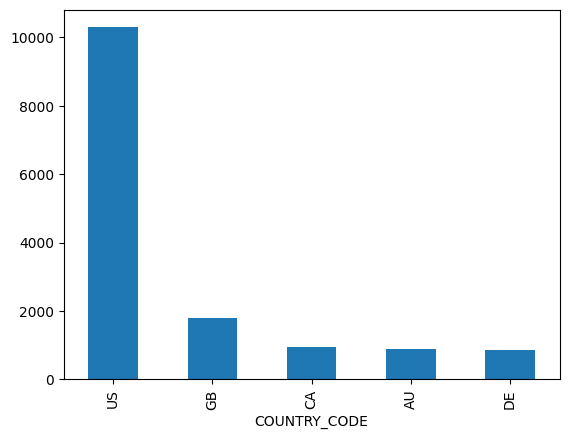

In [46]:
plt_country = elist_order['COUNTRY_CODE'].value_counts().head(5).plot(kind='bar')

In [32]:
categorical_order = elist_order.dtypes[elist_order.dtypes == 'object'].index
print(categorical_order)

elist_order[categorical_order].describe()

Index(['USER_ID', 'ORDER_ID', 'PURCHASE_TS', 'PRODUCT_NAME', 'PRODUCT_ID',
       'PURCHASE_PLATFORM', 'MARKETING_CHANNEL', 'ACCOUNT_CREATION_METHOD',
       'COUNTRY_CODE', 'Unnamed: 13'],
      dtype='object')


,USER_ID,ORDER_ID,PURCHASE_TS,PRODUCT_NAME,PRODUCT_ID,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,Unnamed: 13
count,21864,21864,21864,21864,21864,21864,21781,21781,21826,1
unique,19851,21719,783,9,46,2,5,5,150,1
top,07868dba,844a97334cd107082,2020-12-19 00:00:00,Nintendo Switch,8d0d,website,direct,desktop,US,#REF!
freq,4,2,95,10386,6024,19783,17434,16458,10294,1


### 查看空值以及是否存在异常值

可以看到REFUND_TS字段包含了超过一半以上的空值，但是由于这是关于退款情况的指标，初步假设存在空值的情况是客户没有进行退款的操作，后续与运营团队沟通确定指标是否为客户没有进行退款

两列未命名列基本上全是空值，可能表明实际工作表的列数是12列

In [33]:
elist_order.isnull().sum()

USER_ID                        0
ORDER_ID                       0
PURCHASE_TS                    0
SHIP_TS                        0
REFUND_TS                  18377
PRODUCT_NAME                   0
PRODUCT_ID                     0
USD_PRICE                      5
PURCHASE_PLATFORM              0
MARKETING_CHANNEL             83
ACCOUNT_CREATION_METHOD       83
COUNTRY_CODE                  38
Unnamed: 12                21864
Unnamed: 13                21863
dtype: int64

### 查看另一个工作表的情况，同上步骤

In [34]:
elist_region = pd.read_excel("gamezone-orders-data.xlsx", sheet_name='region')
elist_region.head()

,COUNTRY_CODE,REGION
0,AD,EMEA
1,AE,EMEA
2,AG,NaN
3,AI,NaN
4,AL,EMEA


In [35]:
print(elist_region.shape)
print(elist_region.dtypes)
elist_region.describe()

(192, 2)
COUNTRY_CODE    object
REGION          object
dtype: object


,COUNTRY_CODE,REGION
count,191,169
unique,191,5
top,AD,EMEA
freq,1,98


In [36]:
categorical_region = elist_region.dtypes[elist_region.dtypes == 'object'].index
print(categorical_region)

elist_region[categorical_region].describe()

Index(['COUNTRY_CODE', 'REGION'], dtype='object')


,COUNTRY_CODE,REGION
count,191,169
unique,191,5
top,AD,EMEA
freq,1,98


#### 从上面简单的初步探索，可以发现该数据集包含两个表，其中order表表示公司的各地区各产品销售的情况，region则是国家编号以及国区的对应表，表示order表里面订单所属地区的分类

#### 由于数据约为20k，下面将使用excel以及MySQL进行数据清洗以及透视表做进一步的探索分析